# E-Commerce Customer Segmentation
## Notebook 1: Exploratory Data Analysis & Data Cleaning

**Dataset:** Online Retail II UCI  
**Source:** Kaggle / UCI Machine Learning Repository  
**Period:** 2009–2011, UK-based online retailer  

### Objectives
- Understand the structure and quality of the dataset
- Handle missing values, duplicates, and anomalies
- Engineer new features for further analysis
- Visualize sales trends and customer behavior


In [14]:
# libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset


In [2]:
# Load dataset
df = pd.read_csv(
    "../data/online_retail_II.csv",
    encoding='latin-1'
)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: (1067371, 8)

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


## 2. Data Overview

In [3]:
# Basic info
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Values'] > 0])

=== Data Types ===
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

=== Missing Values ===
             Missing Values  Percentage (%)
Description            4382            0.41
Customer ID          243007           22.77


## Data Quality Issues Identified

| Column | Issue | Action |
|----------|---------|---------|
| Customer ID | 22.77% missing values | Remove rows with missing customer IDs |
| Description | 0.41% missing values | Handle missing values appropriately |
| InvoiceDate | Incorrect data type (`object`) | Convert to `datetime` |
| Invoice | Contains cancelled transactions (`C`) | Remove cancelled invoices |

## Data Cleaning Plan

- Remove records with missing `Customer ID` values.
- Handle missing values in `Description`.
- Convert `InvoiceDate` from `object` to `datetime`.
- Exclude cancelled transactions from the dataset.
- Validate the dataset after cleaning to ensure data consistency before segmentation analysis.

## Business Justification

- Customer segmentation requires a valid customer identifier, making `Customer ID` a critical field.
- Missing values in `Description`, although limited, may affect product-level analysis.
- Converting `InvoiceDate` to a datetime format enables time-series analysis and feature engineering.
- Cancelled transactions do not represent actual purchases and may introduce bias into customer behavior analysis.

## 3. Data Cleaning

### 3.1 Remove Missing Customer IDs
Rows with missing `Customer ID` are dropped because customer segmentation 
requires a valid identifier to track individual customer behavior.


In [4]:
# drop missing values in 'Customer ID' column
print("shape before dropping missing values:", df.shape)

df.dropna(subset=['Customer ID'], inplace=True)

print("shape after dropping missing values:", df.shape)

shape before dropping missing values: (1067371, 8)
shape after dropping missing values: (824364, 8)


### 3.2 Convert InvoiceDate to Datetime 
`InvoiceDate` was stored as `object` type. Converting it to `datetime` enables time-based feature engineering such as Recency calculation in RFM analysis.

In [5]:
# Convert 'InvoiceDate' to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

print(df['InvoiceDate'].dtypes)


datetime64[ns]


### 3.3 Removed Cancellation Transaction 
Invoice starting with `C` indicate cancellations. These are excluded because they not represent actual purchases and would distort customer behavior analysis.

In [6]:
print("Shape before removing cancelled transactions:", df.shape)

df = df[~df['Invoice'].str.startswith('C', na=False)]

print("Shape after removing cancelled transactions:", df.shape)
print(f"Rows removed: {824364 - df.shape[0]}")

Shape before removing cancelled transactions: (824364, 8)
Shape after removing cancelled transactions: (805620, 8)
Rows removed: 18744


### 3.4 Missing values in Description 
the `Description` colums is not used in RFM-based customer segmentation. our analysis focuses on customer behavior - recency, frequency, and monetary values - so missing description have impect are left as-is.

### 4. post-cleaning validation 
After cleaninig, we validate the dataset to ensure all issue have been resolved before moving feature engineering and analysis.

In [7]:
#final dataset shape
print(f"Final dataset shape: {df.shape}")

# info data types and missing values after cleaning
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Values'] > 0])

# cek cancelled transactions
remaining_cancelled_rows = df[df['Invoice'].str.startswith('C', na=False)]
print(f"Remaining cancelled transactions: {remaining_cancelled_rows.shape[0]}")


Final dataset shape: (805620, 8)
=== Data Types ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

=== Missing Values ===
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []
Remaining cancelled transactions: 0


## 5. Featuring Engineering 
### 5.1 Create TotalPrice Column 
A new column `TotalPrice` is created by multiplying `Quantity` by `Price`. 
this represents the total transaction value pre row and will be used to calculate the Monetary component in RFM analysis.


In [8]:
# create a new column 

df['TotalPrice'] = df['Quantity'] * df['Price']

print(df[['TotalPrice', 'Price', 'Quantity']].head())
print("New column 'TotalPrice' created successfully!")

   TotalPrice  Price  Quantity
0       83.40   6.95        12
1       81.00   6.75        12
2       81.00   6.75        12
3      100.80   2.10        48
4       30.00   1.25        24
New column 'TotalPrice' created successfully!


## 6. Exploratory Data Analysis (EDA)
in this section, we explore the dataset visually to uncover patterns in customer behavoir, product performence, adn sales trends .

### 6. Top 10 Countries by total revenue


Country
EIRE          621631.11
Netherlands   554232.34
Germany       431262.46
France        355257.47
Australia     169968.11
Spain         109178.53
Switzerland   100365.34
Sweden         91549.72
Denmark        69862.19
Belgium        65753.42
Name: TotalPrice, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_3024\3550317458.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(x='TotalPrice', y='Country', data=plot_data.reset_index(), color='steelblue', hue='Country', legend=False)


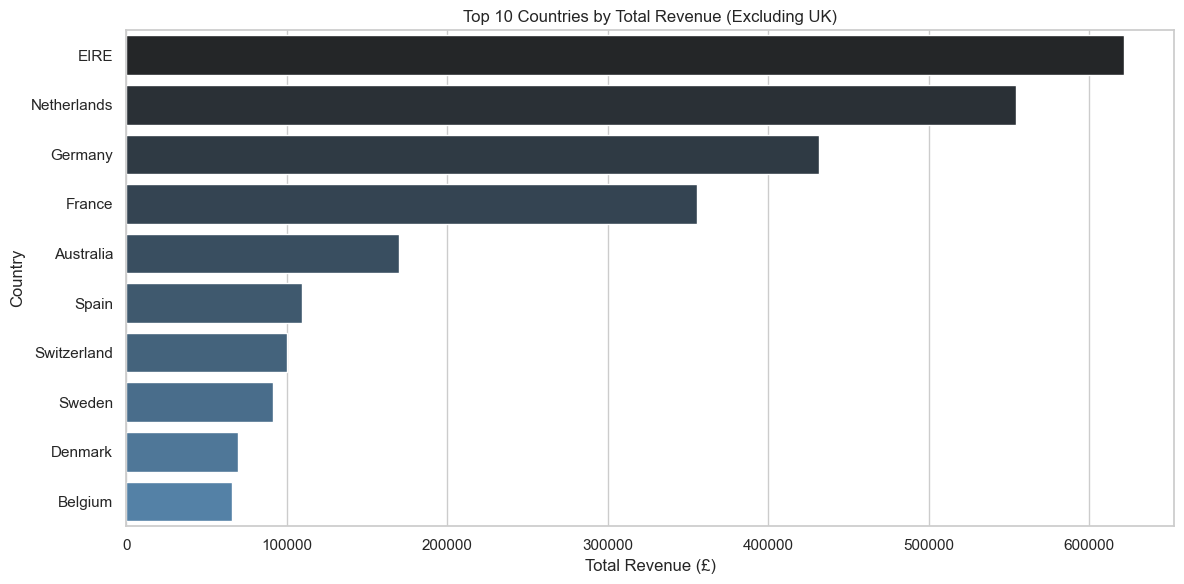

In [9]:
# visualize top 10 countries by total revenue (excluding UK)

plot_data = df.groupby('Country')['TotalPrice'].sum()
plot_data = plot_data[plot_data.index != 'United Kingdom']
plot_data = plot_data.sort_values(ascending=False).head(10)
print(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='TotalPrice', y='Country', data=plot_data.reset_index(), color='steelblue', hue='Country', legend=False)
plt.title('Top 10 Countries by Total Revenue (Excluding UK)')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### 6.2 Top 10 Products by Quantity Sold


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109169
WHITE HANGING HEART T-LIGHT HOLDER     93640
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79913
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                75759
BROCADE RING PURSE                     71129
PACK OF 60 PINK PAISLEY CAKE CASES     55270
60 TEATIME FAIRY CAKE CASES            53495
PACK OF 72 RETROSPOT CAKE CASES        46107
Name: Quantity, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_3024\749029674.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(x='Quantity', y='Description', data=plot_data.reset_index(), color='steelblue', hue='Description', legend=False)


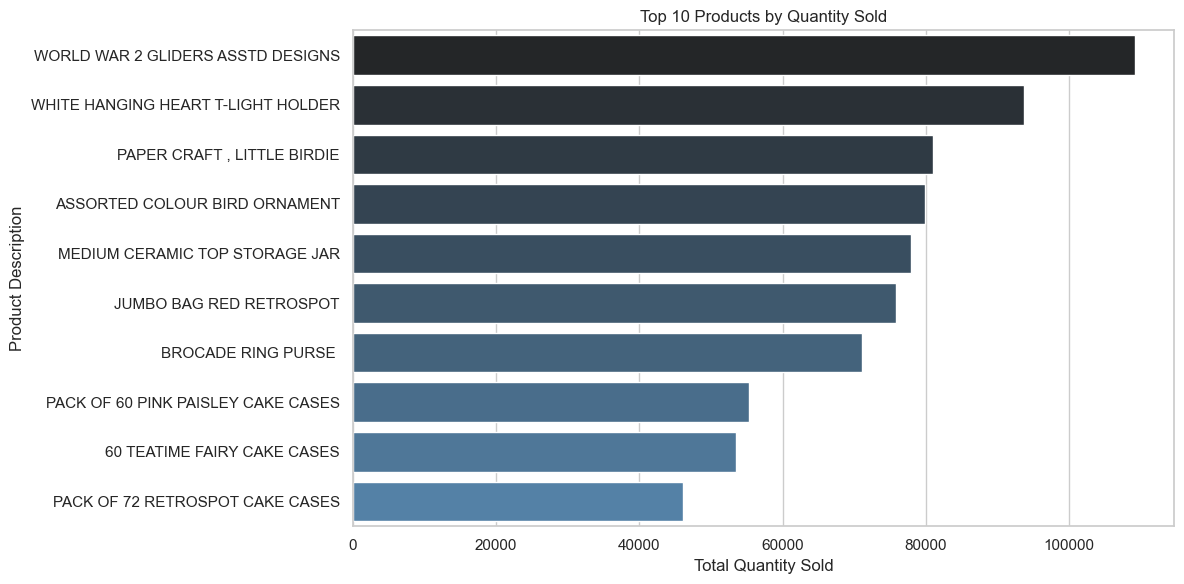

In [10]:
# visualize top 10 products by quantity sold

plot_data = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(x='Quantity', y='Description', data=plot_data.reset_index(), color='steelblue', hue='Description', legend=False)
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

### 6.3 Monthly Sales Trend

0          2009-12
1          2009-12
2          2009-12
3          2009-12
4          2009-12
            ...   
1067366    2011-12
1067367    2011-12
1067368    2011-12
1067369    2011-12
1067370    2011-12
Name: InvoiceDate, Length: 805620, dtype: period[M]


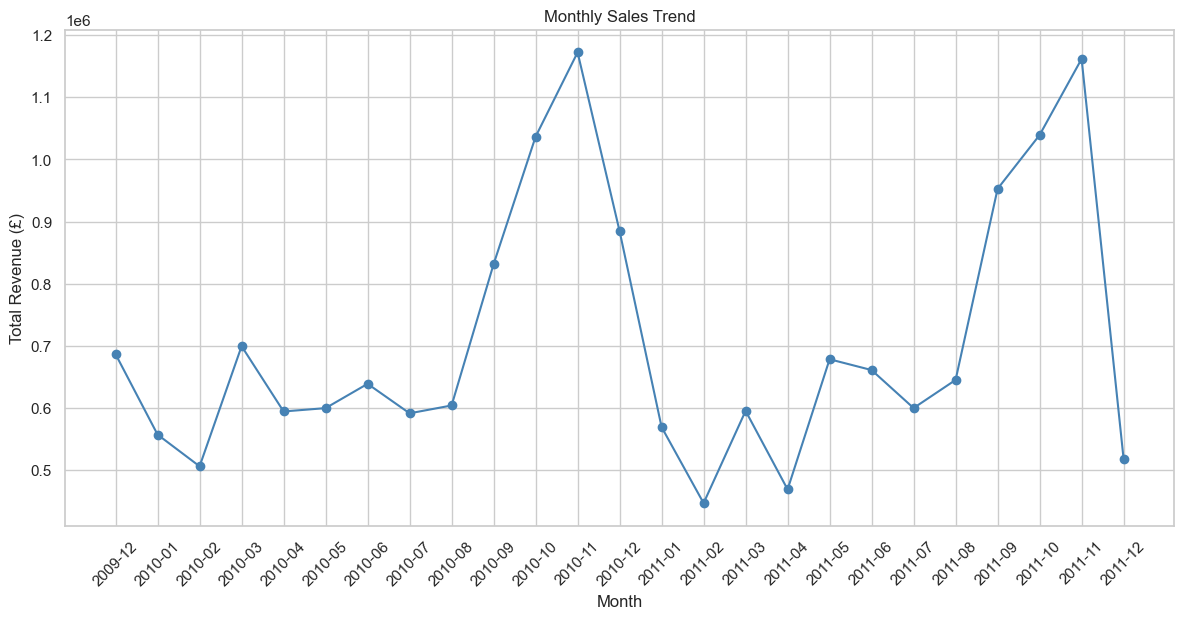

In [ ]:
# visualizing monthly sales trend

extract_month = df['InvoiceDate'].dt.to_period('M')
grouped_data = df.groupby(extract_month)['TotalPrice'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(grouped_data['InvoiceDate'].astype(str), grouped_data['TotalPrice'], marker='o', color='steelblue')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()



### 7. save cleaned dataset

In [15]:
# save clened dataset to a new CSV file
df.to_csv("../data/cleaned_online_retail_II.csv", index=False)

if os.path.exists("../data/cleaned_online_retail_II.csv"):
    print("Cleaned dataset saved successfully!")
else:
    print("Error: Cleaned dataset not saved.")

Cleaned dataset saved successfully!


## Summary

### Dataset Overview

* **Initial Shape:** `1,067,371 rows × 8 columns`
* **Final Shape:** `805,620 rows × 8 columns`

---

## Data Cleaning

### 1. Removed Missing Customer IDs

Rows with missing **Customer ID** were removed because customer segmentation requires a valid identifier to track individual customer behavior.

### 2. Converted `InvoiceDate` to Datetime

The **InvoiceDate** column was originally stored as an `object` data type. It was converted to `datetime` to enable time-based feature engineering, such as calculating **Recency** in RFM analysis.

### 3. Removed Cancelled Transactions

Invoices starting with the letter **`C`** represent cancelled transactions. These records were excluded because they do not reflect actual purchases and could bias customer behavior analysis.

### 4. Missing Values in `Description`

The **Description** column contains a small number of missing values. Since this column is not required for RFM customer segmentation, the missing values were left unchanged.

---

# Key Insights

* **Top Revenue by Country (excluding the United Kingdom):**

  1. Ireland — **621,631.11**
  2. Netherlands
  3. Germany

* **Best-Selling Products:**

  1. **WORLD WAR 2 GLIDERS** — **109,169 units sold**
  2. **WHITE HANGING HEART T-LIGHT HOLDER**
  3. **PAPER CRAFT**

* **Sales Trend (2009–2011):**

  * Sales consistently increased between **September and December**.
  * **November** recorded the highest sales volume, indicating a strong seasonal shopping period.
